# Setup 
(Run these first)

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))

using AttitudeBehaviorDynamicsModel
using LinearAlgebra, Statistics, Distributions
using DelimitedFiles, FileIO, JLD2
using SharedArrays, Graphs
using Colors, GraphPlot
using GaussianMixtures
using CairoMakie

  Activating project at `/scratch/gpfs/CTARNITA/kfinke/SABC/AgentBasedModel`


## Default Parameters

In [2]:
# Default Parameters (don't edit these here, edit them as needed in the code below)

# Behavior Incentives, -1 to 1
β = 0.0

# Attitude Biases, -1 to 1
α = 0.0

# Attitude-Behavior Linkage strength, 0 to 1
λ = 0.0

# Population Size
N = 100

# Behavior Memory Length (for calculating H)
M = 20

# error rate
err = 0.01

# simulation timelimit
timelimit = 50000

# social network type
networkType = "wellmixed"

# type of tracker to save simulation outputs (visual recommended to reproduce plots of the paper)
trackerType ="visual" 

# Attitude update and Behavior update rates
rates = [0.1,0.1]

# the folder where the simulations will be saved
simulationName="reproduceFigures"

#how many repetitions of each simulation do you want
repetitions=25

# you probably don't want to change these unless you're making your own versions of the model (if so, cool!)
attProbsType="model13Version"     # How to calculate attitude update probabilities 
behavProbsType="model13Version"   # How to calculate behavior update probabilities 
λBAdirectionType="lastBehavior"   # how to calculate the direction of λ (see supplemental material for notes on this)
socialInfluenceType="mean"        # how to calculate S
historyDependenceType="mean"      # how to calculate H
;

## Plotting functions

In [3]:
function blank_axis(; 
    xcolor     = :blue,
    ycolor     = :black,
    xlabel     = "",
    ylabel     = "",
    xticks     = nothing,
    yticks     = nothing,
    xaxiswidth = 2,
    yaxiswidth = 2,
    xtickwidth = 2,
    ytickwidth = 2,
    xlabelsize=20,
    ylabelsize=20,
    size       = (500, 500),
    title      =  "",
    padding    = 12
)

    fig = Figure(size = size,figure_padding = (padding, padding, padding, padding))

    ax = Axis(fig[1, 1]; 
        xlabel = xlabel,
        ylabel = ylabel,
        title = title,

        # Tick and label colors
        xticklabelcolor = xcolor,
        yticklabelcolor = ycolor,
        xtickcolor = xcolor,
        ytickcolor = ycolor,
        xlabelcolor = xcolor,
        ylabelcolor = ycolor,

        #label sizes
        xlabelsize=xlabelsize,
        ylabelsize=ylabelsize,

        # Tick widths
        xtickwidth = xtickwidth,
        ytickwidth = ytickwidth,
        xticksize = 8,
        yticksize = 8,

        # Grid off
        xgridvisible = false,
        ygridvisible = false,

        # Spine colors and widths
        bottomspinecolor = xcolor,
        leftspinecolor = ycolor,
        spinewidth = yaxiswidth,

        # Optional: hide top and right spines
        topspinevisible = false,
        rightspinevisible = false,
    )

    if xticks !== nothing
        ax.xticks = xticks
    end
    if yticks !== nothing
        ax.yticks = yticks
    end

    return fig, ax
end

#Define colors
betaBlue = "#4a86e8"
alphaRed = "#ff6370"
lambdaPurple = "#984ea3"
negOnly = "#f7bb7cff"  
negOnlyFaint="#f7bb7c55"
posOnly = "#9fcb8cff"
posOnlyFaint = "#9fcb8c55" 
sponBoth = "#bddaff6d"
inducible = "#ffebb0ff"
inducibleFaint = "#ffebb055"
nodata="#00000000"
sponNeg = "#c8e1bcff"
sponPos = "#fad7b3ff"
sponNegFaint = "#c8e1bc55"
sponPosFaint = "#fad7b355"

movingaverage(g, n) = [i < n ? mean(g[begin:i]) : mean(g[i-n+1:i]) for i in 1:length(g)];

# Timeseries Plots
To create a specific timeseries plot, change the whichPlot to the name of the plot you'd like to generate, or create your own by setting whichPlot to "freestyle" and change the values in the "if whichPlot == "freestyle" section

Simulations have stochasticity, so results will not be identical to those produced in the paper.

If you run the same conditions multiple times, the code will just reuse results it previously generated. So, if you want to rerun the same simulation from scratch, change the simulationName (e.g. simulationName="reproduceFigures2")

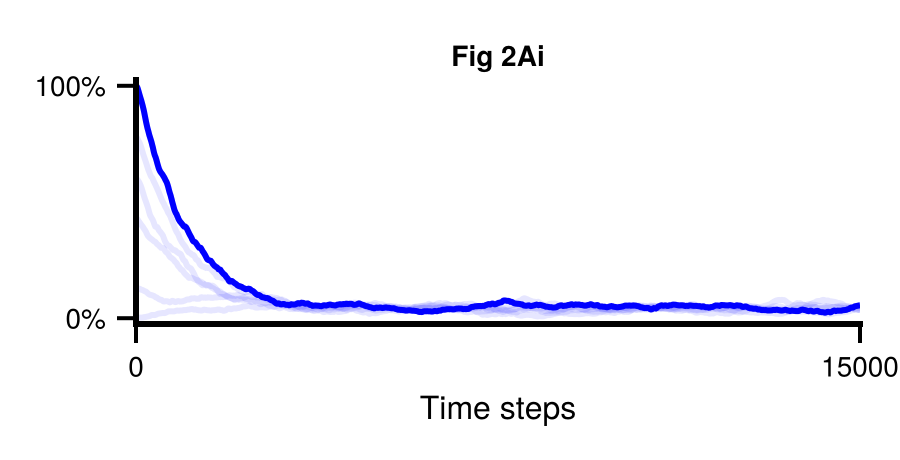

In [123]:
# Run simulations for timeseries plots (or use existing simulations, if found)

##################################################################################################
# Default Parameters (don't edit these, they reset any parameters changed by the if/elseif below)  
##################################################################################################
β = 0.0
α = 0.0
λ = 0.0
err = 0.01
N = 100
M = 20

########################
# Plotting parameters   
########################

startTime=1       # Start time of the plot
plotTL = 15000    # plot time limit
lw=3              # line width
highlight = 3     # which of the simulations to plot in bold color (in order to visually highlight a single trajectory)
plotRed = true    # set to false if you want to hide attitude outcomes
plotBlue= true    # set to false if you want to hide behavior outcomes

repsEach = 1 # how many repetitions to plot from each starting state
numStartingStates = 6 # number of evenly-spaced starting states to simulate/plot
startingStateStep = 1.0/(numStartingStates-1)

###########################################################################################
#   Set whichPlot to the name of the plot you'd like to generate
#   List of options and their parameter values found in the if/elseif statements below
#
#   Want to set your own parameter values? set whichPlot = "freestyle"
#   and edit the parameters in the corresponding block ("if whichPlot == "freestyle"...")
###########################################################################################
whichPlot = "Fig 2Ai"

if whichPlot == "freestyle"
    titleString="insert title here"
    # set your own parameter values here!
    β = 0.0
    α= 0.0
    λ = 0.0

    highlight=2
    plotBlue=true
    plotRed=true
    
    simulationName="reproduceFigures"

elseif whichPlot=="Fig 2Ai"
    titleString="Fig 2Ai"
    β=-0.1
    highlight = 1
    plotRed=false
    simulationName="reproduceFigures"
    
elseif whichPlot=="Fig 2Aii"
    titleString="Fig 2Aii"
    β=-0.01
    highlight = 5
    plotRed=false
    simulationName="reproduceFigures"

elseif whichPlot=="Fig 2Bi"
    titleString="Fig 2Bi"
    α=-0.1
    highlight = 2
    simulationName="reproduceFigures"
    plotBlue=false
    
elseif whichPlot=="Fig 2Bii"
    titleString="Fig 2Bii"
    α=-0.01
    highlight = 2
    simulationName="reproduceFigures"
    plotBlue=false

elseif whichPlot=="Fig 2Ci"
    titleString="Fig 2Ci"
    λ = 0.1
    highlight = 3
    simulationName="reproduceFigures"

elseif whichPlot=="Fig 2Cii"
    titleString="Fig 2Cii"
    λ = 0.75
    highlight = 2
    simulationName="reproduceFigures"

elseif whichPlot == "Fig S7A short"
    titleString="Fig S7A short"
    highlight=2
    plotRed=false
    plotTL = 1000
    simulationName="reproduceFigures"
    
elseif whichPlot == "Fig S7A long"
    titleString="Fig S7A long"
    highlight=2
    plotRed=false
    startTime= 49000
    plotTL = 50000
    simulationName="reproduceFigures"

elseif whichPlot=="Fig S7B"
    titleString="Fig S7B"
    highlight=3
    plotBlue=false
    plotTL = 15000
    simulationName="reproduceFigures"

elseif whichPlot == "Fig S8 Ai-iv"
    N =10 #i N=10, ii N=100, iii N=1000, iv N=10000
    titleString="Fig S8 Ai-iv N = $N"
    highlight=2
    plotRed=false
    plotTL = 50000
    simulationName="reproduceFigures"

elseif whichPlot == "Fig S8 Bi-iv"
    N =10 #i N=10, ii N=100, iii N=1000, iv N=10000
    titleString="Fig S8 Bi-iv N = $N"
    highlight=3
    plotBlue=false
    plotTL = 50000
    err = 0.00
    simulationName="reproduceFigures"

elseif whichPlot == "Fig S8 Ci-iv"
    N =10 #i N=10, ii N=100, iii N=1000, iv N=10000
    λ = 0.2
    titleString="Fig S8 Ci-iv lamdba = $λ N = $N"
    highlight=3
    plotTL = 50000
    simulationName="reproduceFigures"

elseif whichPlot=="Fig S11 A-D"
    β=0.12#A β=-0.09, B β=-0.1, C β=-0.11, D β=-0.12,
    λ = 0.75
    titleString="Fig S11 A-D $β lambda $λ"
    highlight = 2
    simulationName="reproduceFigures"
    plotTL = 50000
else
    error("Error: Need to specify whichPlot to one of the options, or define your own")
end

######################################################################################################################

# Load File
paramStr = getParamString(N,M,rates,λ,λ,β,α,err,networkType,trackerType,attProbsType,λBAdirectionType,socialInfluenceType,behavProbsType,historyDependenceType,timelimit)
getPath = "../simulations/$simulationName/$paramStr"
jld_path = getPath*"/all_reps.jld2"

# check if the simulations already exist
if isfile(jld_path)
    f = jldopen(jld_path, "r") 
    has_rep = haskey(f, "pop_1")
    close(f)
else
    has_rep = false
end

# if the simulations don't already exist, run them
if !has_rep
    println("Simulation file doesn't exist, creating...")

    # loop through all starting states
    for (rr, startingLoc) in enumerate(range(0,1,step=startingStateStep))

        # create the starting state of the population
        attitudes=ones(N) .*-1
        behaviors=ones(N,M) .*-1
        attitudes[rand(N) .< 1-startingLoc] .*= -1
        behaviors[rand(N) .< 1-startingLoc,:] .*= -1
        startingPop=generatePop(N,M,rates,λ,λ,β,α,err,networkType,attProbsType,λBAdirectionType,socialInfluenceType,behavProbsType,historyDependenceType,lowercase(trackerType),attitudes=attitudes,behaviors=behaviors)

        reps = repsEach*rr

        # run simulation!
        println("Starting simulation alpha=$α, beta=$β, rates=$rates, λ=$λ, M=$M  ....")
        @time simulate(reps,N,M,rates,λ,λ,β,α,err,timelimit,simulationName,startingPop=startingPop,attProbsType=attProbsType,λBAdirectionType=λBAdirectionType,socialInfluenceType=socialInfluenceType,behavProbsType=behavProbsType,historyDependenceType=historyDependenceType,trackFreq=Int(ceil(timelimit/5000)),trackerType=trackerType,networkType=networkType,untilFixation=false,savePop=true)
    end

end

# generate y label
ylabel = "Frequency of "
if plotRed
    ylabel = ylabel * "A+"
end
if plotBlue && plotRed
    ylabel = ylabel * " & "
end
if plotBlue
    ylabel = ylabel * "B+"
end

#set up blank plot
fig, ax = blank_axis(
    xcolor = :black,
    ycolor = :black,
    xlabel = "Time steps",
    #ylabel = ylabel,
    xticks = ([1,plotTL], ["0", "$plotTL"]),
    yticks = ([-1,1], ["0%", "100%"]),
    xaxiswidth = 3,
    yaxiswidth = 3,
    size = (450,230),#(200, 170)
    title=titleString,
    padding = 20,
    ylabelsize=16,
    xlabelsize=16
)
limits!(ax, startTime, plotTL, -1.05, 1.05)

# Plot each repetition in faded color
for rr in 1:repsEach*numStartingStates
    
    f = jldopen(jld_path, "r")
    pop = f["pop_$rr"]
    close(f)

    if plotRed
        lines!(ax, pop.tracker.times, movingaverage(pop.tracker.attMean, 4); color = (:red, 0.1), linewidth = 3)
    end
    if plotBlue
        lines!(ax, pop.tracker.times, movingaverage(pop.tracker.behavMean, 4); color = (:blue, 0.1), linewidth = 3)
    end
end

# Plot the highlighted simulation in a bold color
rr = highlight
f = jldopen(jld_path, "r")
pop = f["pop_$rr"]
close(f)
if plotRed
    lines!(ax, pop.tracker.times, movingaverage(pop.tracker.attMean, 4); color = :red, linewidth = 3)
end
if plotBlue
    lines!(ax, pop.tracker.times, movingaverage(pop.tracker.behavMean, 4); color = :blue, linewidth = 3)
end

# save and display plot
save("../plots/timeseries $(titleString).png", fig)
fig

# 1D equilibrium plots
Null + β, Null + α, Null + λ, Null + β with λ = 75%

Generating the following plots requires a large number of simulations (50 repetitions per data point)

So, the following code will use pre-generated data.

If you'd like to run your own simulations to generate 1D or 2D equilibrium plots, see README

### Functions for generating 1D equilibria plots
(run these first)

In [124]:
eqPlotSize = (450,230)
gap=2

# Julia doesn't have a built in nanmean function, so I define them here
function nanmean3to1(A::Array{<:Real, 3})
    [mean(A[i, :, :][.!isnan.(A[i, :, :])]) for i in axes(A, 1)]
end
function nanmean2to1(A::AbstractArray{<:Real, 2})
    [mean(skipmissing(filter(!isnan, A[i, :]))) for i in axes(A, 1)]
end
# find the equilibrium/a from the given data
function getEquilibria(αrange,βrange,λrange,meansAllFile,reps,timerange,attorbehav)
    
    # Initialize equilibrium arrays for plotting
    # last two dimensions meaning: two possible starting points (-,+), three possible ending points (+,-,all)
    eqsMeans = zeros(length(αrange),length(βrange),length(λrange),2,3)
    eqsStds = zeros(length(αrange),length(βrange),length(λrange),2,3)
    
    # Load condensed output files (created by running simulations first then running save_compressed_model14
    meansAll = load(meansAllFile)["$(attorbehav)MeansAll"]
    
    # go through all αrange,βrange,λrange values
    for (aa,αα) in enumerate(αrange),(bb,ββ) in enumerate(βrange),(ll,λλ) in enumerate(λrange)
    
        # lists to save unknown number of outcomes for each category
        # for each outcome, save the full timerange (to calculate std within simulation)
        negToPos = zeros(length(timerange),0)
        posToPos = zeros(length(timerange),0)
        negToNeg = zeros(length(timerange),0)
        posToNeg = zeros(length(timerange),0)
        negToAll = zeros(length(timerange),0)
        posToAll = zeros(length(timerange),0)
            
        #loop through reps and starting points
        for rr in 1:reps, (ss,startSign) in enumerate([-1,+1])
            if startSign == -1

                # Start negative, end all
                negToAll=hcat(negToAll,meansAll[aa,bb,ll,timerange,rr,ss])
                
                if mean(meansAll[aa,bb,ll,timerange,rr,ss]) > 0
                    # Start negative, end positive
                    negToPos=hcat(negToPos,meansAll[aa,bb,ll,timerange,rr,ss])
                else
                    # Start negative, end negative
                    negToNeg=hcat(negToNeg,meansAll[aa,bb,ll,timerange,rr,ss])
                end
            else

                # Start positive, end all
                posToAll=hcat(posToAll,meansAll[aa,bb,ll,timerange,rr,ss])
                
                if mean(meansAll[aa,bb,ll,timerange,rr,ss]) > 0
                    # Start positive, end positive
                    posToPos=hcat(posToPos,meansAll[aa,bb,ll,timerange,rr,ss])
                else
                    # Start positive, end negative
                    posToNeg=hcat(posToNeg,meansAll[aa,bb,ll,timerange,rr,ss])
                end
            end
        end

        # save mean and std of equilibria from each outcome
        eqsMeans[aa,bb,ll,1,1] = mean(mean(negToNeg))
        eqsMeans[aa,bb,ll,1,2] = mean(mean(negToPos))
        eqsMeans[aa,bb,ll,2,1] = mean(mean(posToNeg))
        eqsMeans[aa,bb,ll,2,2] = mean(mean(posToPos))
        eqsMeans[aa,bb,ll,1,3] = mean(mean(negToAll))
        eqsMeans[aa,bb,ll,2,3] = mean(mean(posToAll))
        
        (length(negToNeg[1,:]) > 0) && (eqsStds[aa,bb,ll,1,1] = std([negToNeg...]))
        (length(negToPos[1,:]) > 0) && (eqsStds[aa,bb,ll,1,2] = std([negToPos...]))
        (length(posToNeg[1,:]) > 0) && (eqsStds[aa,bb,ll,2,1] = std([posToNeg...]))
        (length(posToPos[1,:]) > 0) && (eqsStds[aa,bb,ll,2,2] = std([posToPos...]))
        (length(negToAll[1,:]) > 0) && (eqsStds[aa,bb,ll,1,3] = std([negToAll...]))
        (length(posToAll[1,:]) > 0) && (eqsStds[aa,bb,ll,2,3] = std([posToAll...]))
        
    end
    return eqsMeans, eqsStds
end


# find the equilibrium/a from the given data
function getEquilibriaOLD(αrange,βrange,λrange,behavMeansAllFile,attMeansAllFile,reps,timerange)
    
    # Initialize equilibrium arrays for plotting
    # last two dimensions meaning: two possible starting points (-,+), three possible ending points (+,-,all)
    eqsMeansBehav = zeros(length(αrange),length(βrange),length(λrange),2,3)
    eqsStdsBehav = zeros(length(αrange),length(βrange),length(λrange),2,3)
    eqsMeansAtt = zeros(length(αrange),length(βrange),length(λrange),2,3)
    eqsStdsAtt = zeros(length(αrange),length(βrange),length(λrange),2,3)
    
    # Load condensed output files (created by running simulations first then running save_compressed_model14
    behavMeansAll = load(behavMeansAllFile)["behavMeansAll"]
    attMeansAll = load(attMeansAllFile)["attMeansAll"]
    
    # go through all αrange,βrange,λrange values
    for (aa,αα) in enumerate(αrange),(bb,ββ) in enumerate(βrange),(ll,λλ) in enumerate(λrange)
    
        # lists to save unknown number of outcomes for each category
        # for each outcome, save the full timerange (to calculate std within simulation)
        negToPos = zeros(length(timerange),0)
        posToPos = zeros(length(timerange),0)
        behavNegToNeg = zeros(length(timerange),0)
        behavPosToNeg = zeros(length(timerange),0)
        behavNegToAll = zeros(length(timerange),0)
        behavPosToAll = zeros(length(timerange),0)
        
    
        attNegToPos = zeros(length(timerange),0)
        attPosToPos = zeros(length(timerange),0)
        attNegToNeg = zeros(length(timerange),0)
        attPosToNeg = zeros(length(timerange),0)
        attNegToAll = zeros(length(timerange),0)
        attPosToAll = zeros(length(timerange),0)
            
        #loop through reps and starting points
        for rr in 1:reps, (ss,startSign) in enumerate([-1,+1])
            if startSign == -1

                # Start negative, end all
                behavNegToAll=hcat(behavNegToAll,behavMeansAll[aa,bb,ll,timerange,rr,ss])
                attNegToAll=hcat(attNegToAll,attMeansAll[aa,bb,ll,timerange,rr,ss])
                
                if mean(behavMeansAll[aa,bb,ll,timerange,rr,ss]) > 0
                    # Start negative, end positive
                    behavNegToPos=hcat(behavNegToPos,behavMeansAll[aa,bb,ll,timerange,rr,ss])
                    attNegToPos=hcat(attNegToPos,attMeansAll[aa,bb,ll,timerange,rr,ss])
                else
                    # Start negative, end negative
                    behavNegToNeg=hcat(behavNegToNeg,behavMeansAll[aa,bb,ll,timerange,rr,ss])
                    attNegToNeg=hcat(attNegToNeg,attMeansAll[aa,bb,ll,timerange,rr,ss])
                end
            else

                # Start positive, end all
                behavPosToAll=hcat(behavPosToAll,behavMeansAll[aa,bb,ll,timerange,rr,ss])
                attPosToAll=hcat(attPosToAll,attMeansAll[aa,bb,ll,timerange,rr,ss])
                
                if mean(behavMeansAll[aa,bb,ll,timerange,rr,ss]) > 0
                    # Start positive, end positive
                    behavPosToPos=hcat(behavPosToPos,behavMeansAll[aa,bb,ll,timerange,rr,ss])
                    attPosToPos=hcat(attPosToPos,attMeansAll[aa,bb,ll,timerange,rr,ss])
                else
                    # Start positive, end negative
                    behavPosToNeg=hcat(behavPosToNeg,behavMeansAll[aa,bb,ll,timerange,rr,ss])
                    attPosToNeg=hcat(attPosToNeg,attMeansAll[aa,bb,ll,timerange,rr,ss])
                end
            end
        end

        # save mean and std of equilibria from each outcome
        eqsMeansBehav[aa,bb,ll,1,1] = mean(mean(behavNegToNeg))
        eqsMeansBehav[aa,bb,ll,1,2] = mean(mean(behavNegToPos))
        eqsMeansBehav[aa,bb,ll,2,1] = mean(mean(behavPosToNeg))
        eqsMeansBehav[aa,bb,ll,2,2] = mean(mean(behavPosToPos))
        eqsMeansBehav[aa,bb,ll,1,3] = mean(mean(behavNegToAll))
        eqsMeansBehav[aa,bb,ll,2,3] = mean(mean(behavPosToAll))
        
        (length(behavNegToNeg[1,:]) > 0) && (eqsStdsBehav[aa,bb,ll,1,1] = std([behavNegToNeg...]))
        (length(behavNegToPos[1,:]) > 0) && (eqsStdsBehav[aa,bb,ll,1,2] = std([behavNegToPos...]))
        (length(behavPosToNeg[1,:]) > 0) && (eqsStdsBehav[aa,bb,ll,2,1] = std([behavPosToNeg...]))
        (length(behavPosToPos[1,:]) > 0) && (eqsStdsBehav[aa,bb,ll,2,2] = std([behavPosToPos...]))
        (length(behavNegToAll[1,:]) > 0) && (eqsStdsBehav[aa,bb,ll,1,3] = std([behavNegToAll...]))
        (length(behavPosToAll[1,:]) > 0) && (eqsStdsBehav[aa,bb,ll,2,3] = std([behavPosToAll...]))
        
        
        eqsMeansAtt[aa,bb,ll,1,1] = mean(mean(attNegToNeg))
        eqsMeansAtt[aa,bb,ll,1,2] = mean(mean(attNegToPos))
        eqsMeansAtt[aa,bb,ll,2,1] = mean(mean(attPosToNeg))
        eqsMeansAtt[aa,bb,ll,2,2] = mean(mean(attPosToPos))
        eqsMeansAtt[aa,bb,ll,1,3] = mean(mean(attNegToAll))
        eqsMeansAtt[aa,bb,ll,2,3] = mean(mean(attPosToAll))
        
        (length(attNegToNeg[1,:]) > 0) && (eqsStdsAtt[aa,bb,ll,1,1] = std([attNegToNeg...]))
        (length(attNegToPos[1,:]) > 0) && (eqsStdsAtt[aa,bb,ll,1,2] = std([attNegToPos...]))
        (length(attPosToNeg[1,:]) > 0) && (eqsStdsAtt[aa,bb,ll,2,1] = std([attPosToNeg...]))
        (length(attPosToPos[1,:]) > 0) && (eqsStdsAtt[aa,bb,ll,2,2] = std([attPosToPos...]))
        (length(attNegToAll[1,:]) > 0) && (eqsStdsAtt[aa,bb,ll,1,3] = std([attNegToAll...]))
        (length(attPosToAll[1,:]) > 0) && (eqsStdsAtt[aa,bb,ll,2,3] = std([attPosToAll...]))
    end
    return eqsMeansBehav, eqsStdsBehav, eqsMeansAtt, eqsStdsAtt
end

# plotting function for equilibrium scatter plots
function scatterPlotEqs(ax,xrange,eqsMeans,eqsStds,color;erroroffset=0,markershape=:circle,elw=2,alpha=1)
    # xrange and eqs arrays should be pre-indexed to desired range
    # xrange is 1D, eqsMeans and eqsStds are 1D-3D ??? TODO is this possible?

    # equilibrium points
    scatter!(ax,xrange, eqsMeans, color=color, alpha=alpha)

    # error bars
    for (ii,xx) in enumerate(xrange)
        lines!(ax,[xx-erroroffset,xx-erroroffset], [(eqsMeans[ii] + eqsStds[ii]), (eqsMeans[ii] - eqsStds[ii])], color=color, alpha=alpha)
    end
end


scatterPlotEqs (generic function with 1 method)

### Null + β equilibrium plot (Fig. 2Aiii)

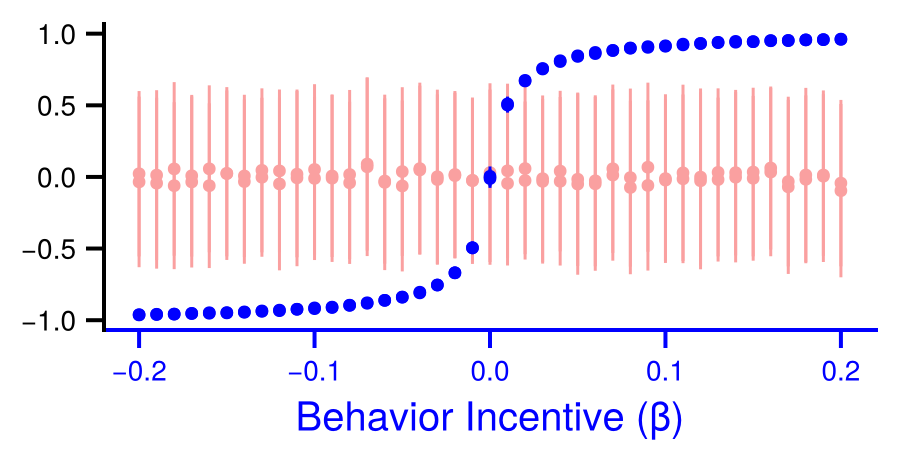

In [125]:
# Null + β equilibrium plot
αrange = [0.0]
βrange = range(-0.2,0.2,step=0.005)
λrange = [0.0]

behavMeansAllFile = "../simulations/compressedSims/sampleSimulations/behavMeansAll α = $αrange , β = $βrange , λ = $λrange .jld"
attMeansAllFile = "../simulations/compressedSims/sampleSimulations/attMeansAll α = $αrange , β = $βrange , λ = $λrange .jld"

reps = 50
timerange = 2400:2500

# get equilibria
eqsMeansBehav, eqsStdsBehav = getEquilibria(αrange,βrange,λrange,behavMeansAllFile,reps,timerange,"behav")
eqsMeansAtt, eqsStdsAtt = getEquilibria(αrange,βrange,λrange,attMeansAllFile,reps,timerange,"att")

# plot equilibria
fig, ax = blank_axis(xcolor = :blue, ycolor = :black, xlabel = "Behavior Incentive (β)", ylabel = "", size = eqPlotSize)

scatterPlotEqs(ax,βrange[1:gap:end],nanmean2to1(eqsMeansAtt[1,1:gap:end,1,1,:]),nanmean2to1(eqsStdsAtt[1,1:gap:end,1,1,:]),"#FAA0A0",elw=1)
scatterPlotEqs(ax,βrange[1:gap:end],nanmean2to1(eqsMeansAtt[1,1:gap:end,1,2,:]),nanmean2to1(eqsStdsAtt[1,1:gap:end,1,2,:]),"#FAA0A0",elw=1)
scatterPlotEqs(ax,βrange[1:gap:end],nanmean2to1(eqsMeansBehav[1,1:gap:end,1,1,:]),nanmean2to1(eqsStdsBehav[1,1:gap:end,1,1,:]),:blue)
scatterPlotEqs(ax,βrange[1:gap:end],nanmean2to1(eqsMeansBehav[1,1:gap:end,1,2,:]),nanmean2to1(eqsStdsBehav[1,1:gap:end,1,2,:]),:blue)

fig

### Null + α equilibrium plot (Fig. 2Aiii)

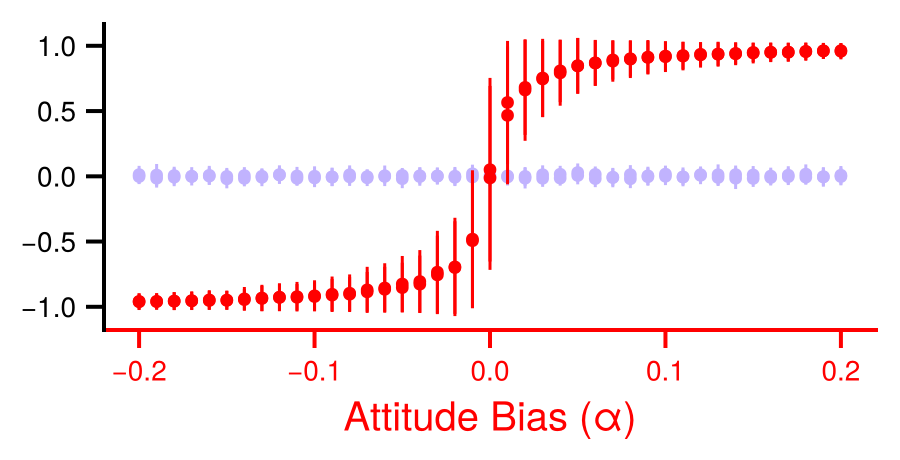

In [7]:
# Null + α equilibrium plot

αrange = range(-0.2,0.2,step=0.005)
βrange = [0.0]
λrange = [0.0]

behavMeansAllFile = "../simulations/compressedSims/sampleSimulations/behavMeansAll α = $αrange , β = $βrange , λ = $λrange .jld"
attMeansAllFile = "../simulations/compressedSims/sampleSimulations/attMeansAll α = $αrange , β = $βrange , λ = $λrange .jld"

reps = 50
timerange = 2400:2500

# get equilibria
eqsMeansBehav, eqsStdsBehav = getEquilibria(αrange,βrange,λrange,behavMeansAllFile,reps,timerange,"behav")
eqsMeansAtt, eqsStdsAtt = getEquilibria(αrange,βrange,λrange,attMeansAllFile,reps,timerange,"att")

# plot equilibria
fig, ax = blank_axis(xcolor = :red, ycolor = :black, xlabel = "Attitude Bias (α)", ylabel = "", size = eqPlotSize)

scatterPlotEqs(ax,αrange[1:gap:end],nanmean2to1(eqsMeansBehav[1:gap:end,1,1,1,:]),nanmean2to1(eqsStdsBehav[1:gap:end,1,1,1,:]),"#c1b3feff",elw=1)
scatterPlotEqs(ax,αrange[1:gap:end],nanmean2to1(eqsMeansBehav[1:gap:end,1,1,2,:]),nanmean2to1(eqsStdsBehav[1:gap:end,1,1,2,:]),"#c1b3feff",elw=1)
scatterPlotEqs(ax,αrange[1:gap:end],nanmean2to1(eqsMeansAtt[1:gap:end,1,1,1,:]),nanmean2to1(eqsStdsAtt[1:gap:end,1,1,1,:]),:red)
scatterPlotEqs(ax,αrange[1:gap:end],nanmean2to1(eqsMeansAtt[1:gap:end,1,1,2,:]),nanmean2to1(eqsStdsAtt[1:gap:end,1,1,2,:]),:red)

fig

### Null + λ equilibrium plot (Fig. 2Ciii)

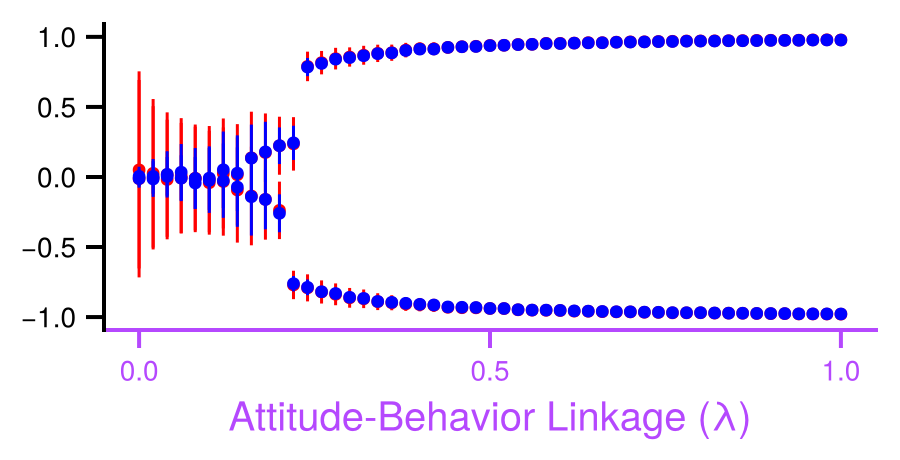

In [8]:
# Null + λ equilibrium plot
αrange = [0.0]
βrange = [0.0]
λrange = range(0.0,1.0,step=0.01)

behavMeansAllFile = "../simulations/compressedSims/sampleSimulations/behavMeansAll α = $αrange , β = $βrange , λ = $λrange .jld"
attMeansAllFile = "../simulations/compressedSims/sampleSimulations/attMeansAll α = $αrange , β = $βrange , λ = $λrange .jld"

reps = 50
timerange = 2400:2500

# get equilibria
eqsMeansBehav, eqsStdsBehav = getEquilibria(αrange,βrange,λrange,behavMeansAllFile,reps,timerange,"behav")
eqsMeansAtt, eqsStdsAtt = getEquilibria(αrange,βrange,λrange,attMeansAllFile,reps,timerange,"att")

#TODO maybe combine equilibria? since only one outcome

# plot equilibria
fig, ax = blank_axis(xcolor = "#b548fe", ycolor = :black, xlabel = "Attitude-Behavior Linkage (λ)", ylabel = "", size = eqPlotSize)

#TODO before a certain point, plot only 1, then use that method to plot alpha and beta versions
scatterPlotEqs(ax,λrange[1:gap:end],nanmean2to1(eqsMeansAtt[1,1,1:gap:end,1,:]),nanmean2to1(eqsStdsAtt[1,1,1:gap:end,1,:]),:red)
scatterPlotEqs(ax,λrange[1:gap:end],nanmean2to1(eqsMeansAtt[1,1,1:gap:end,2,:]),nanmean2to1(eqsStdsAtt[1,1,1:gap:end,2,:]),:red)
scatterPlotEqs(ax,λrange[1:gap:end],nanmean2to1(eqsMeansBehav[1,1,1:gap:end,1,:]),nanmean2to1(eqsStdsBehav[1,1,1:gap:end,1,:]),:blue)
scatterPlotEqs(ax,λrange[1:gap:end],nanmean2to1(eqsMeansBehav[1,1,1:gap:end,2,:]),nanmean2to1(eqsStdsBehav[1,1,1:gap:end,2,:]),:blue)

fig

### Null + β with λ = 75% (Fig. 3A)

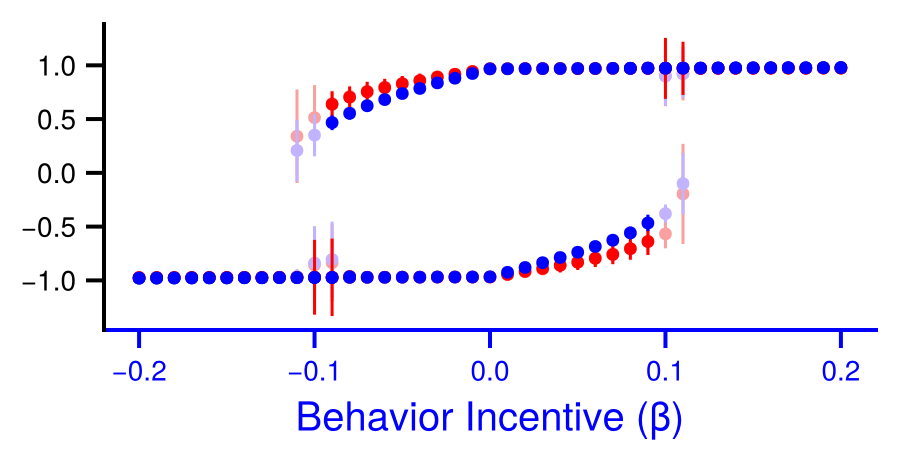

In [9]:
# Null + β with λ = 75%
gap = 2
αrange = [0.0]
βrange = range(-0.2,0.2,step=0.005)
λrange = [0.75]

behavMeansAllFile = "../simulations/compressedSims/sampleSimulations/behavMeansAll α = $αrange , β = $βrange , λ = $λrange .jld"
attMeansAllFile = "../simulations/compressedSims/sampleSimulations/attMeansAll α = $αrange , β = $βrange , λ = $λrange .jld"

reps = 50


# plot equilibria
fig, ax = blank_axis(xcolor = :blue, ycolor = :black, xlabel = "Behavior Incentive (β)", ylabel = "", size = eqPlotSize)

#########################################################################################################################################
# First, plot short-term equilibria to show temporary states
#########################################################################################################################################

timerange = 200:300 

# get equilibria
eqsMeansBehav, eqsStdsBehav = getEquilibria(αrange,βrange,λrange,behavMeansAllFile,reps,timerange,"behav")
eqsMeansAtt, eqsStdsAtt = getEquilibria(αrange,βrange,λrange,attMeansAllFile,reps,timerange,"att")


# plot equilibria
scatterPlotEqs(ax,βrange[1:gap:end],eqsMeansAtt[1,1:gap:end,1,1,1],eqsStdsAtt[1,1:gap:end,1,1,1],"#FAA0A0")
scatterPlotEqs(ax,βrange[1:gap:end],eqsMeansAtt[1,1:gap:end,1,2,1],eqsStdsAtt[1,1:gap:end,1,2,1],"#FAA0A0")
scatterPlotEqs(ax,βrange[1:gap:end],eqsMeansAtt[1,1:gap:end,1,1,2],eqsStdsAtt[1,1:gap:end,1,1,2],"#FAA0A0")
scatterPlotEqs(ax,βrange[1:gap:end],eqsMeansAtt[1,1:gap:end,1,2,2],eqsStdsAtt[1,1:gap:end,1,2,2],"#FAA0A0")
scatterPlotEqs(ax,βrange[1:gap:end],eqsMeansBehav[1,1:gap:end,1,1,1],eqsStdsBehav[1,1:gap:end,1,1,1],"#c1b3feff")
scatterPlotEqs(ax,βrange[1:gap:end],eqsMeansBehav[1,1:gap:end,1,2,1],eqsStdsBehav[1,1:gap:end,1,2,1],"#c1b3feff")
scatterPlotEqs(ax,βrange[1:gap:end],eqsMeansBehav[1,1:gap:end,1,1,2],eqsStdsBehav[1,1:gap:end,1,1,2],"#c1b3feff")
scatterPlotEqs(ax,βrange[1:gap:end],eqsMeansBehav[1,1:gap:end,1,2,2],eqsStdsBehav[1,1:gap:end,1,2,2],"#c1b3feff")

#########################################################################################################################################
# Then, plot long-term equilibria 
#########################################################################################################################################

timerange = 2400:2500

# get equilibria
eqsMeansBehav, eqsStdsBehav = getEquilibria(αrange,βrange,λrange,behavMeansAllFile,reps,timerange,"behav")
eqsMeansAtt, eqsStdsAtt = getEquilibria(αrange,βrange,λrange,attMeansAllFile,reps,timerange,"att")

# plot equilibria
scatterPlotEqs(ax,βrange[1:gap:end],eqsMeansAtt[1,1:gap:end,1,1,1],eqsStdsAtt[1,1:gap:end,1,1,1],:red)
scatterPlotEqs(ax,βrange[1:gap:end],eqsMeansAtt[1,1:gap:end,1,2,1],eqsStdsAtt[1,1:gap:end,1,2,1],:red)
scatterPlotEqs(ax,βrange[1:gap:end],eqsMeansAtt[1,1:gap:end,1,1,2],eqsStdsAtt[1,1:gap:end,1,1,2],:red)
scatterPlotEqs(ax,βrange[1:gap:end],eqsMeansAtt[1,1:gap:end,1,2,2],eqsStdsAtt[1,1:gap:end,1,2,2],:red)
scatterPlotEqs(ax,βrange[1:gap:end],eqsMeansBehav[1,1:gap:end,1,1,1],eqsStdsBehav[1,1:gap:end,1,1,1],:blue)
scatterPlotEqs(ax,βrange[1:gap:end],eqsMeansBehav[1,1:gap:end,1,2,1],eqsStdsBehav[1,1:gap:end,1,2,1],:blue)
scatterPlotEqs(ax,βrange[1:gap:end],eqsMeansBehav[1,1:gap:end,1,1,2],eqsStdsBehav[1,1:gap:end,1,1,2],:blue)
scatterPlotEqs(ax,βrange[1:gap:end],eqsMeansBehav[1,1:gap:end,1,2,2],eqsStdsBehav[1,1:gap:end,1,2,2],:blue)

fig

### Null + α with λ = 75% (Fig S10A)

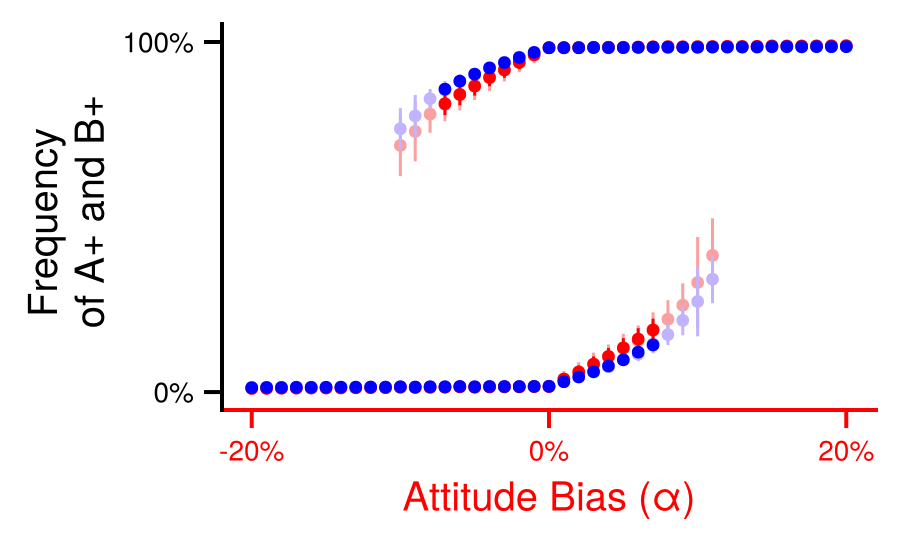

In [10]:
# Null + α equilibrium plot
gap = 2
αrange = range(-0.2,0.2,step=0.005)
βrange = 0.0
λrange = [0.75]

behavMeansAllFile = "../simulations/compressedSims/sampleSimulations/behavMeansAll α = $αrange , β = $βrange , λ = $λrange .jld"
attMeansAllFile = "../simulations/compressedSims/sampleSimulations/attMeansAll α = $αrange , β = $βrange , λ = $λrange .jld"

reps = 50

# plot equilibria
xtickss=([αrange[1],0.0,αrange[end]],["$(round(Int,αrange[1]*100))%","0%","$(round(Int,αrange[end]*100))%"])
fig, ax = blank_axis(xcolor = :red, ycolor = :black, xlabel = "Attitude Bias (α)", size = (450,270), title = "", ylabel = "Frequency \n of A+ and B+", xticks = xtickss, yticks = ([-1,1], ["0%", "100%"]))

#########################################################################################################################################
# First, plot short-term equilibria to show temporary states
#########################################################################################################################################
reps = 50
timerange = 200:300 

# get equilibria
eqsMeansBehav, eqsStdsBehav = getEquilibria(αrange,βrange,λrange,behavMeansAllFile,reps,timerange,"behav")
eqsMeansAtt, eqsStdsAtt = getEquilibria(αrange,βrange,λrange,attMeansAllFile,reps,timerange,"att")

#TODO maybe combine equilibria? since only one outcome

# plot equilibria
scatterPlotEqs(ax,αrange[1:gap:end],eqsMeansAtt[1:gap:end,1,1,1,1],eqsStdsAtt[1:gap:end,1,1,1,1],"#FAA0A0")
scatterPlotEqs(ax,αrange[27:gap:end],eqsMeansAtt[27:gap:end,1,1,2,1],eqsStdsAtt[27:gap:end,1,1,2,1],"#FAA0A0")
scatterPlotEqs(ax,αrange[1:gap:56],eqsMeansAtt[1:gap:56,1,1,1,2],eqsStdsAtt[1:gap:56,1,1,1,2],"#FAA0A0")
scatterPlotEqs(ax,αrange[21:gap:end],eqsMeansAtt[21:gap:end,1,1,2,2],eqsStdsAtt[21:gap:end,1,1,2,2],"#FAA0A0")
scatterPlotEqs(ax,αrange[1:gap:end],eqsMeansBehav[1:gap:end,1,1,1,1],eqsStdsBehav[1:gap:end,1,1,1,1],"#c1b3feff")
scatterPlotEqs(ax,αrange[27:gap:end],eqsMeansBehav[27:gap:end,1,1,2,1],eqsStdsBehav[27:gap:end,1,1,2,1],"#c1b3feff")
scatterPlotEqs(ax,αrange[1:gap:56],eqsMeansBehav[1:gap:56,1,1,1,2],eqsStdsBehav[1:gap:56,1,1,1,2],"#c1b3feff")
scatterPlotEqs(ax,αrange[21:gap:end],eqsMeansBehav[21:gap:end,1,1,2,2],eqsStdsBehav[21:gap:end,1,1,2,2],"#c1b3feff")

#########################################################################################################################################
# Then, plot long-term equilibria 
#########################################################################################################################################

reps = 50
timerange = 2400:2500 #TODO will having different length time ranges affect the error bars across plots?

# get equilibria
eqsMeansBehav, eqsStdsBehav = getEquilibria(αrange,βrange,λrange,behavMeansAllFile,reps,timerange,"behav")
eqsMeansAtt, eqsStdsAtt = getEquilibria(αrange,βrange,λrange,attMeansAllFile,reps,timerange,"att")


scatterPlotEqs(ax,αrange[1:gap:56],nanmean2to1(eqsMeansAtt[1:gap:56,1,1,1,:]),nanmean2to1(eqsStdsAtt[1:gap:56,1,1,1,:]),:red,elw=1)
scatterPlotEqs(ax,αrange[27:gap:end],nanmean2to1(eqsMeansAtt[27:gap:end,1,1,2,:]),nanmean2to1(eqsStdsAtt[27:gap:end,1,1,2,:]),:red,elw=1)
scatterPlotEqs(ax,αrange[1:gap:56],nanmean2to1(eqsMeansBehav[1:gap:56,1,1,1,:]),nanmean2to1(eqsStdsBehav[1:gap:56,1,1,1,:]),:blue,elw=1)
scatterPlotEqs(ax,αrange[27:gap:end],nanmean2to1(eqsMeansBehav[27:gap:end,1,1,2,:]),nanmean2to1(eqsStdsBehav[27:gap:end,1,1,2,:]),:blue,elw=1)


save("../plots/1D eq α with λ 75.png", fig)
fig

# 2D equilibrium plots

Generating the following plots requires a large number of simulations (50 repetitions per pixel)

So, the following code will use pre-generated data.

If you'd like to run your own simulations to generate 1D or 2D equilibrium plots, see README

## Functions (run these first)

In [11]:
# functions (run these first)

# classify a set of simulations into a regime
function classifyCategoryNumber(behavMeansPosStart,behavMeansNegStart; edges=range(-1,1.1,step=0.1),peakThresh=1250,closenessThresh=0.1)
    # bin the data
    posBins = putInBins(behavMeansPosStart,edges)
    negBins = putInBins(behavMeansNegStart,edges)

    # identify the number of peaks in the data
    # starting from 100% B+ and A+
    posPeaks = numPeaks(posBins,peakThresh)
    # starting from 100% B- and A-
    negPeaks = numPeaks(negBins,peakThresh)

    # Categorize outcomes
    if posPeaks == 2 && negPeaks == 2
        return 3 #back and forth oscillations
    elseif posPeaks == 2 && negPeaks == 1
        return 2 #pos state temporary
    elseif posPeaks == 1 && negPeaks == 2
        return 5 #neg state temporary
    elseif posPeaks == 1 && negPeaks == 1
        # check if peaks are the same or different
        posMean = mean(mean(behavMeansPosStart[500:end,:]))
        negMean = mean(mean(behavMeansNegStart[500:end,:]))
        if abs(posMean-negMean) > closenessThresh
            return 4 #alternative stable states
        else
            #check if shared peak is positive or negative
            meanMean = mean([posMean,negMean])
            if meanMean < 0
                return 1 #neg only
            else
                return 6 #pos only
            end
        end
    else
        println("wrong number of peaks pos=$posPeaks neg=$negPeaks")
        return 0 # no regime classification
    end
end;

# put data into bins by frequency of B+ or A+
function putInBins(data,edges)
    bins = zeros(length(edges)-1)
    
    for (ee,edge) in enumerate(edges[1:length(edges)-1])
        
        mask = (data[:] .>= edge) .&& (data[:] .< edges[ee+1])
        bins[ee] = sum(mask)
    end
    
    return bins
end;

# calculate the number of peaks in the data
function numPeaks(bins,threshMin;peakRange=2)
    mask = bins .> threshMin
    for mm in range(2,length(mask)-1)
        for ii in range(1,peakRange) 
            mask[mm]  =  mask[mm] && bins[mm] > bins[max(1,mm-ii)] && bins[mm] > bins[min(length(mask),mm+ii)]
        end
    end
    for ii in range(1,peakRange) 
        mask[1] = mask[1] && bins[1] > bins[1+ii]
        mask[end] = mask[end] && bins[end] > bins[length(bins)-ii]
    end
   return sum(mask)
end;

## Select which plot to generate

To create a specific plot, change the whichPlot to the name of the plot you'd like to generate.

This section defaults to using saved simulation data provided on github. 

If you'd like to run your own simulations, see instructions in README.
s2")

In [135]:
#################################################
# Default Parameters, unless changed below      #
#################################################
N = 100
M = 20
err = 0.01
timelimit = 50000
repetitions=25

###########################################################################################
#   Set whichPlot to the name of the plot you'd like to generate
#   List of options and their parameter values found in the if/elseif statements below
###########################################################################################
whichPlot = "Fig. 5B"


titleString = "$(whichPlot)"

if whichPlot == "Fig. 3F"
    simulationName="sampleSimulations"
    αrange = [0.0]
    βrange = range(-0.2,0.2,step=0.02)
    λrange = range(0.0,1.0,step=0.02)
    repetitions=25

elseif whichPlot == "Fig. 5B"
    simulationName="sampleSimulations"
    αrange = [-0.1]
    βrange = range(-0.3,0.3,step=0.02)
    λrange = range(0.0,1.0,step=0.02)
    repetitions=50

elseif whichPlot == "Fig. 5D"
    simulationName="sampleSimulations"
    αrange = [0.1]
    βrange = range(-0.3,0.3,step=0.02)
    λrange = range(0.0,1.0,step=0.02)
    repetitions=50

elseif whichPlot == "Fig. 5E"
    simulationName="sampleSimulations"
    αrange = [0.2]
    βrange = range(-0.3,0.3,step=0.02)
    λrange = range(0.0,1.0,step=0.02)
    repetitions=50

elseif whichPlot == "Fig. 5F"
    simulationName="sampleSimulations"
    αrange = range(-0.5,0.5,step=0.05)
    βrange = range(-0.5,0.5,step=0.05)
    λrange = [0.9]
    repetitions=50
    uselambda=false

elseif whichPlot == "Fig. 5G"
    simulationName="sampleSimulations"
    αrange = range(-0.5,0.5,step=0.05)
    βrange = range(-0.5,0.5,step=0.05)
    λrange = [0.1]
    repetitions=50
    uselambda=false
    
else
    error("need to specify whichPlot to one of the options, or define your own")
end

# plotting attitude or behavior outcomes?
# note: we only include behavior outcomes in our sampleSimulations
attOrBehav = "behav"

attOrBehavMeansAllFile = "../simulations/compressedSims/$(simulationName)/$(attOrBehav)MeansAll α = $αrange , β = $βrange , λ = $λrange .jld"
saveFileName = "../simulations/compressedSims/$(simulationName)/$(attOrBehav)Categories α = $αrange , β = $βrange , λ = $λrange .jld"


"../simulations/compressedSims/sampleSimulations/behavCategories α = [-0.1] , β = -0.3:0.02:0.3 , λ = 0.0:0.02:1.0 .jld"

## Categorize and save (if categories already exist, load them)

In [136]:
# threshold for identifying gaps between peaks
peakThresh=25*repetitions

# save yourself from accidentally re-running this if the categories file has already been generated
# if you do want to replace the existing file, set overwrite = true
overwrite = true
if isfile(saveFileName) && !overwrite
    println("file already exits at $saveFileName, only can overwrite if overwrite is set to true")
else
    categories = zeros(length(αrange),length(βrange),length(λrange))
    if !isfile(attOrBehavMeansAllFile)
        println()
        println("no file $attOrBehavMeansAllFile")
    else 
        # load data saved from bulk simulation runs
        attOrBehavMeansAll = load(attOrBehavMeansAllFile)["$(attOrBehav)MeansAll"]
        for (aa,__) in enumerate(αrange),(bb,__) in enumerate(βrange),(ll,__) in enumerate(λrange)
            categories[aa,bb,ll] = classifyCategoryNumber(attOrBehavMeansAll[aa,bb,ll,:,:,1],attOrBehavMeansAll[aa,bb,ll,:,:,2],peakThresh=peakThresh)
        end
    end
    save(saveFileName,"categories",categories)
    print("saved! $saveFileName")
end

saved! ../simulations/compressedSims/sampleSimulations/behavCategories α = [-0.1] , β = -0.3:0.02:0.3 , λ = 0.0:0.02:1.0 .jld

## Plot and save

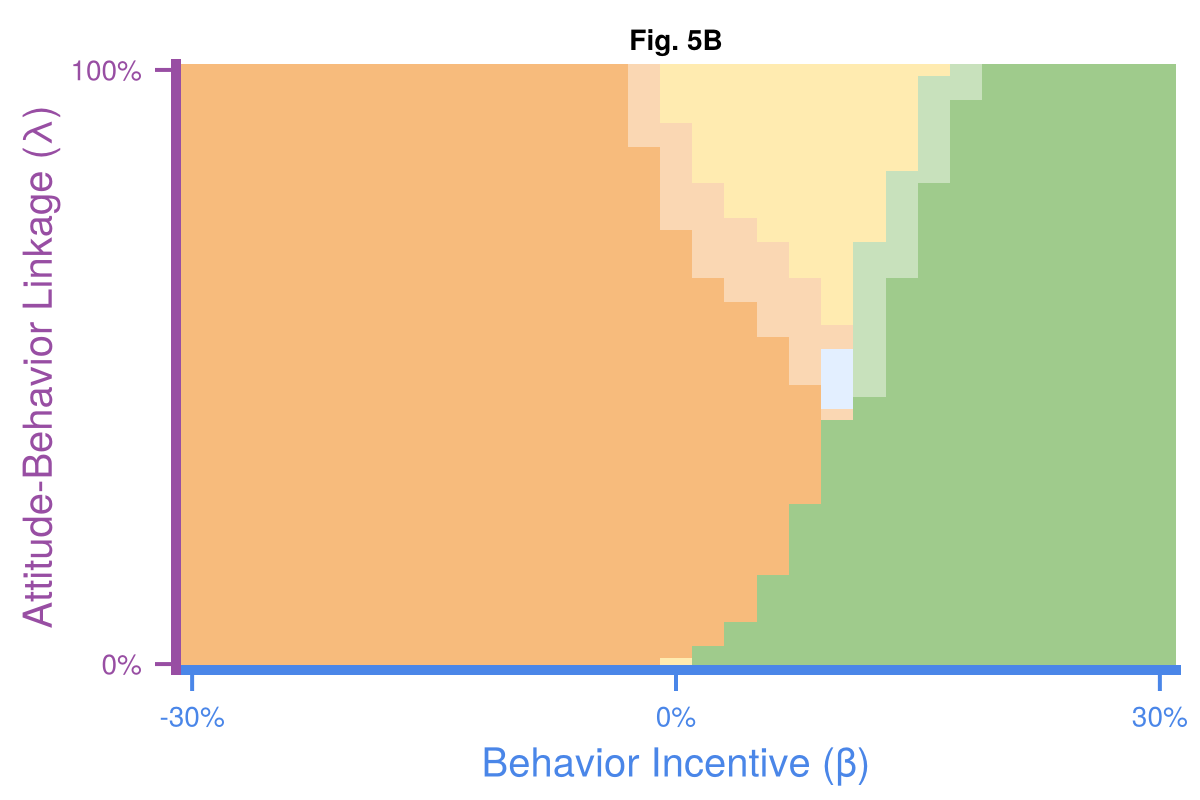

In [137]:
# load categories file
categories = load(saveFileName)["categories"]

# Determine which axes to plot based on which parameter is fixed
if length(αrange) == 1 # plot β vs λ
    fig, ax = blank_axis(xcolor = betaBlue, ycolor = lambdaPurple, yticks=([1,length(λrange)],["0%","100%"]), xticks=([1,findfirst(βrange.==0.0),length(βrange)],["$(round(Int,βrange[1]*100))%","0%","$(round(Int,βrange[end]*100))%"]),xlabel = "Behavior Incentive (β)", ylabel = "Attitude-Behavior Linkage (λ)", xaxiswidth=5, yaxiswidth=5,size = (600,400), title = "$titleString")
    categoriesToPlot = categories[1,:,:]
    
elseif length(βrange) == 1 # plot α vs λ
    fig, ax = blank_axis(xcolor = alphaRed, ycolor = lambdaPurple, yticks=([1,length(λrange)],["0%","100%"]), xticks=([1,findfirst(αrange.==0.0),length(αrange)],["$(round(Int,αrange[1]*100))%","0%","$(round(Int,αrange[end]*100))%"]) ,xlabel = "Attitude Bias (α)", ylabel = "Attitude-Behavior Linkage (λ)", xaxiswidth=5, yaxiswidth=5,size = (600,400), title = "$titleString")
    categoriesToPlot = categories[:,1,:]
    
elseif length(λrange) == 1 # plot β vs α 
    fig, ax = blank_axis(xcolor = betaBlue, ycolor = alphaRed, yticks=([1,findfirst(αrange.==0.0),length(αrange)],["$(round(Int,αrange[1]*100))%","0%","$(round(Int,αrange[end]*100))%"]), xticks=([1,findfirst(αrange.==0.0),length(βrange)],["$(round(Int,βrange[1]*100))%","0%","$(round(Int,βrange[end]*100))%"]),xlabel = "Behavior Incentive (β)", ylabel = "Attitude Bias (α)", xaxiswidth=5, yaxiswidth=5,size = (600,600), title = titleString)
    categoriesToPlot = transpose(categories[:,:,1])
    
else
    print("can't detect axes to plot!")
end

# plot heatmap
if min(categories...)==0
    # (at least one pixel failed, include "no data" color)
    heatmap!(ax,categoriesToPlot,colormap=[nodata,negOnly,sponNeg,sponBoth,inducible,sponPos,posOnly],colorrange=(0,6), interpolate=false)
else
    heatmap!(ax,categoriesToPlot;colormap=[negOnly,sponNeg,sponBoth,inducible,sponPos,posOnly],colorrange=(1, 6), interpolate=false)
end

# save and display plot
save("../plots/$(titleString).png", fig)
fig

# 3D Equlibrium Plots

## Functions (run these first)

In [13]:
function erode_mask(mask::BitMatrix; iters=1)
    m, n = size(mask)
    out = copy(mask)

    for _ in 1:iters
        new = falses(m, n)
        for i in 2:m-1, j in 2:n-1
            new[i,j] = all(out[i-1:i+1, j-1:j+1])
        end
        out = new
    end

    return out
end

function dilate_mask(mask::BitMatrix; iters=1)
    m, n = size(mask)
    out = copy(mask)

    for _ in 1:iters
        new = falses(m, n)
        for i in 2:m-1, j in 2:n-1
            new[i,j] = any(out[i-1:i+1, j-1:j+1])
        end
        out = new
    end

    return out
end

# simple mean (box) blur for Z
function box_blur(Z::AbstractMatrix{<:Real}; r::Int=1)
    Zf = Float32.(Z)
    m, n = size(Zf)
    out = similar(Zf)
    area = Float32((2r+1)*(2r+1))

    # clamp-to-edge indexing
    idx(i,L) = i < 1 ? 1 : (i > L ? L : i)

    @inbounds for i in 1:m, j in 1:n
        s = 0f0
        for di in -r:r, dj in -r:r
            ii = idx(i+di, m); jj = idx(j+dj, n)
            s += Zf[ii, jj]
        end
        out[i,j] = s/area
    end
    out
end

opening(mask; k=1) = erode_mask(dilate_mask(mask; iters=k); iters=k)
closing(mask; k=1) = dilate_mask(erode_mask(mask; iters=k); iters=k)

closing (generic function with 1 method)

## Select which plots to generate

In [128]:
#################################################
# Default Parameters, unless changed below      #
#################################################
N = 100
M = 20
err = 0.01
timelimit = 50000
networkType = "wellmixed"
trackerType ="visual" 
rates = [0.1,0.1]
attProbsType="model13Version"
λBAdirectionType="lastBehavior" 
socialInfluenceType="mean" 
behavProbsType="model13Version"
historyDependenceType="mean"
repetitions=25
###################################################

whichPlot = "Fig. 3B"

titleString = "$(whichPlot)"
mirror=false
uselambda = true

# parameter ranges for the plots in the paper (all other parameters set to default values)
if whichPlot == "Fig. 3B"
    αrange = [0.0]
    βrange = range(-0.2,0.0,step=0.02)
    λrange = range(0.0,1.0,step=0.02)
    simulationName="sampleSimulations"
    mirror =true
    lowres=true
    
else
    error("need to specify whichPlot to one of the options, or define your own")
end

reps = repetitions

25

In [129]:

attMeansAllFile = "../simulations/compressedSims/$(simulationName)/attMeansAll α = $αrange , β = $βrange , λ = $λrange .jld"
behavMeansAllFile = "../simulations/compressedSims/$(simulationName)/behavMeansAll α = $αrange , β = $βrange , λ = $λrange .jld"

for whichTimeRange in ["short","long"]
    if whichTimeRange == "short"
        timerange = 500:600
    else
        timerange = 2400:2500
    end
    saveEqsMeansBehavFileName = "../simulations/compressedSims/$(simulationName)/eqsMeansBehavAll time = $timerange, α = $αrange , β = $βrange , λ = $λrange .jld"
    
    overwrite = true
    if isfile(saveEqsMeansBehavFileName) && !overwrite
        println("file already exits at $(saveEqsMeansBehavFileName), only can overwrite if overwrite is set to true")
    else
    
        # Categorize and save
        eqsMeansBehavAll = zeros(length(αrange),length(βrange),length(λrange),2,3)
        eqsStdsBehavAll = zeros(length(αrange),length(βrange),length(λrange),2,3)
        #eqsMeansAttAll = zeros(length(αrange),length(βrange),length(λrange),2,3)
        #eqsStdsAttAll = zeros(length(αrange),length(βrange),length(λrange),2,3)
        

        if !isfile(behavMeansAllFile)
            println()
            println("no file $behavMeansAllFile")
        elseif !isfile(attMeansAllFile)
            println()
            println("no file $attMeansAllFile")
        else 
            # get equilibria
            eqsMeansBehav, eqsStdsBehav = getEquilibria(αrange,βrange,λrange,behavMeansAllFile,reps,timerange,"behav")
            eqsMeansBehavAll[:,:,:,:,:] = eqsMeansBehav
            eqsStdsBehavAll[:,:,:,:,:] = eqsStdsBehav
            #eqsMeansAttAll[:,:,:,:,:] = eqsMeansAtt
            #eqsStdsAttAll[:,:,:,:,:] = eqsStdsAtt
        end

    
        #saveAll
        save("../simulations/compressedSims/$(simulationName)/eqsMeansBehavAll time = $timerange, α = $αrange , β = $βrange , λ = $λrange .jld", "eqsMeansBehavAll", eqsMeansBehavAll)
        save("../simulations/compressedSims/$(simulationName)/eqsStdsBehavAll time = $timerange, α = $αrange , β = $βrange , λ = $λrange .jld", "eqsStdsBehavAll", eqsStdsBehavAll)
        #save("../simulations/compressedSims/$(simulationName)/eqsMeansAttAll time = $timerange, α = $αrange , β = $βrange , λ = $λrange .jld", "eqsMeansAttAll", eqsMeansAttAll)
        #save("../simulations/compressedSims/$(simulationName)/eqsStdsAttAll time = $timerange, α = $αrange , β = $βrange , λ = $λrange .jld", "eqsStdsAttAll", eqsStdsAttAll)
        println("saved! $(simulationName) equlibria, time = $timerange")
    end
end

saved! sampleSimulations equlibria, time = 500:600
saved! sampleSimulations equlibria, time = 2400:2500


## Calculate equlibria and save

## Load and Plot equlibria

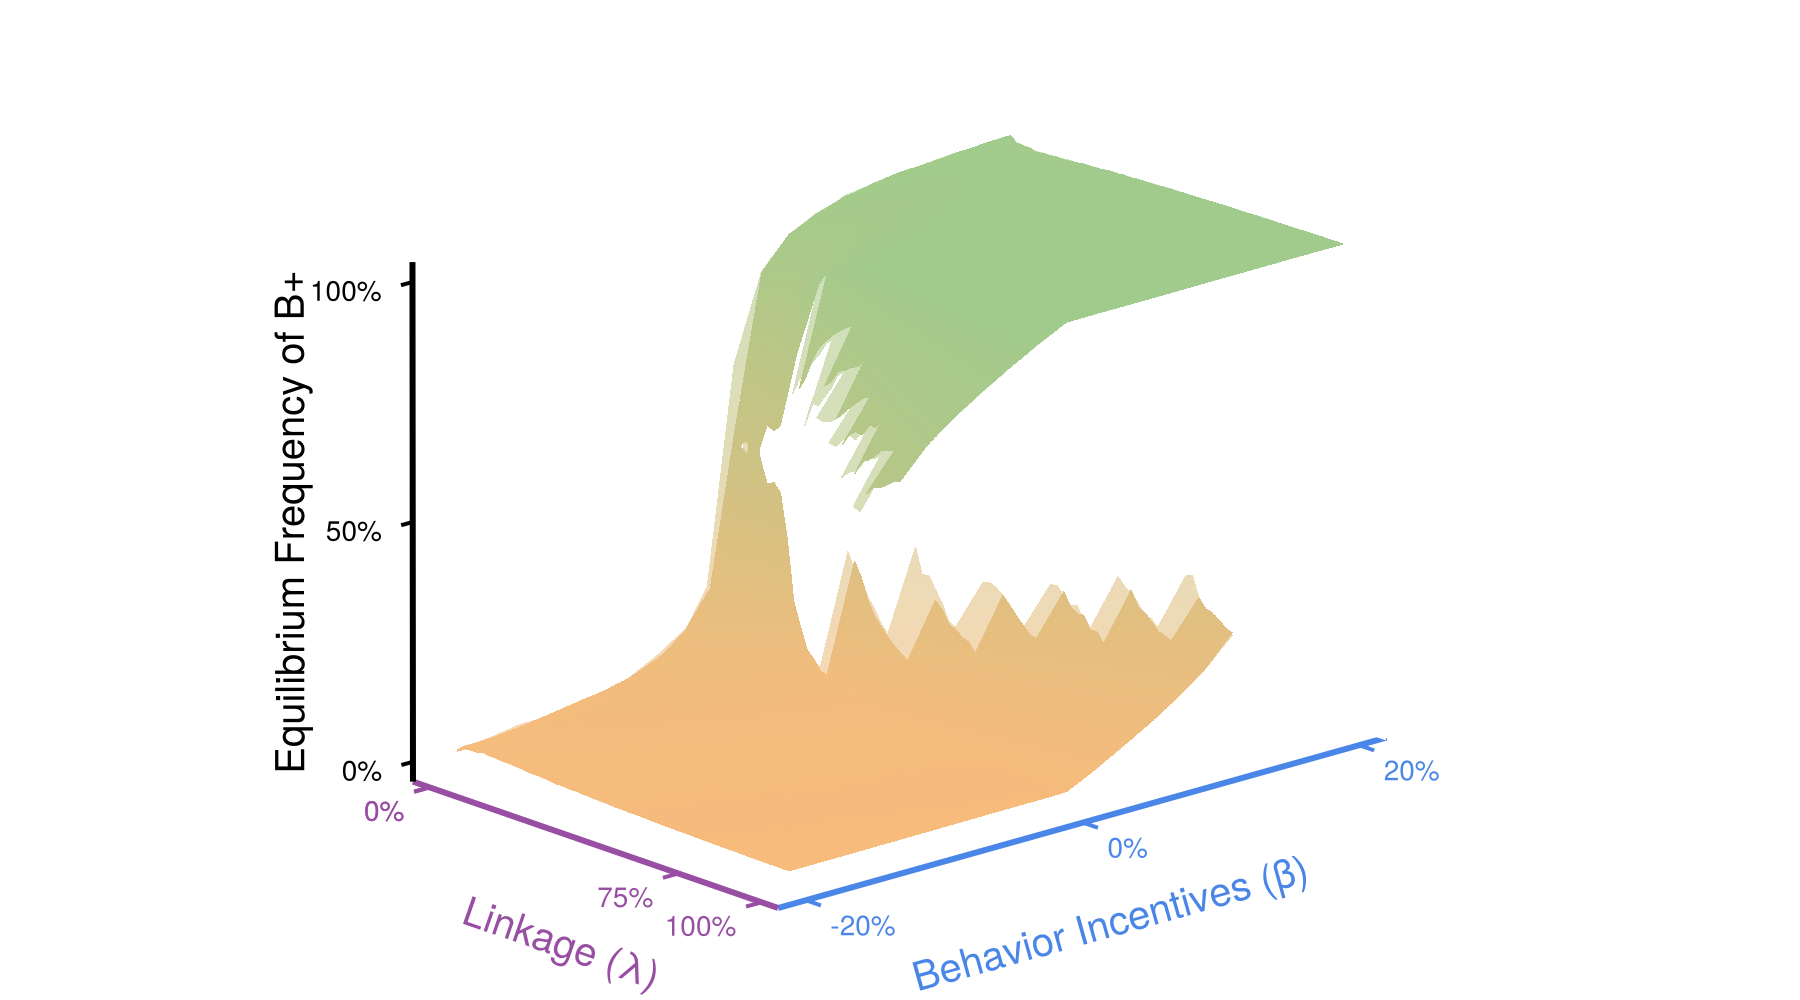

In [130]:
# setup plot axes
xcolor = betaBlue
ycolor=lambdaPurple 
spinewidth = 3
tickwidth =2
labelsize=20
fig = Figure(size = (900, 500))

xtickss=([βrange[1],0.0,βrange[1]*-1],["$(round(Int,βrange[1]*100))%","0%","$(round(Int,βrange[1]*-100))%"])
ytickss=([λrange[1],0.0,0.75,λrange[end]],["$(round(Int,λrange[1]*100))%","0%","75%","$(round(Int,λrange[end]*100))%"])
ztickss=([-1,0,1],["0%","50%","100%"])

ax = Axis3(fig[1,1], 
    aspect = :equal,

    # Axis and tick labels
    xlabel = "Behavior Incentives (β)",
    ylabel = "Linkage (λ)",
    zlabel = "Equilibrium Frequency of B+",
    xticks = xtickss,
    yticks = ytickss,
    zticks = ztickss,

    # Tick and label colors
    xticklabelcolor = xcolor,
    yticklabelcolor = ycolor,
    xtickcolor = xcolor,
    ytickcolor = ycolor,
    xlabelcolor = xcolor,
    ylabelcolor = ycolor,

    #label sizes
    xlabelsize=labelsize,
    ylabelsize=labelsize,
    zlabelsize=labelsize,

    # Tick widths
    xtickwidth = tickwidth,
    ytickwidth = tickwidth,
    ztickwidth = tickwidth,
    xticksize = 8,
    yticksize = 8,

    # Grid off
    xgridvisible = false,
    ygridvisible = false,
    zgridvisible = false,

    # Spine colors and widths
    xspinecolor_1 = xcolor,
    yspinecolor_1 = ycolor,
    xspinecolor_2 = :white,
    yspinecolor_2 = :white,
    zspinecolor_2 = :white,
    xspinecolor_3 = :white,
    yspinecolor_3 = :white,
    zspinecolor_3 = :white,
    xspinecolor_4 = :white,
    yspinecolor_4 = :white,
    zspinecolor_4 = :white,
    xspinewidth = spinewidth,
    yspinewidth = spinewidth,
    zspinewidth = spinewidth)

    # Optional: hide top and right spines
    #topspinevisible = false,
    #rightspinevisible = false)

#cmap = cgrad([colorant"#f7bb7c",colorant"#ffebb0",colorant"#9fcb8c"])

#########################################################################################################################################
# First, plot short term
######################################################################################################################################### 
timerange = 500:600

cmap = cgrad([colorant"#fad7b3",colorant"#c8e1bc"])
# load equlibria
eqsMeansBehavAll = load("../simulations/compressedSims/$(simulationName)/eqsMeansBehavAll time = $timerange, α = $αrange , β = $βrange , λ = $λrange .jld", "eqsMeansBehavAll")


Z1 = eqsMeansBehavAll[1,:,:,1,3]
Z2 = eqsMeansBehavAll[1,:,:,2,3]
#Z1_masked = ifelse.(Z1 .< 0.1, Z1, NaN)
#Z2_masked = ifelse.(Z2 .> -0.1, Z2, NaN)
#Z2_masked = ifelse.(isnan.(eqsMeansBehavAll[1,:,:,2,2]), NaN, eqsMeansBehavAll[1,:,:,2,2])
mask = isnan.(eqsMeansBehavAll[1,:,:,2,2])

mask1 = closing(mask; k=1)      # fill tiny holes
mask2 = opening(mask1; k=1)      # remove speckles
mask3 = dilate_mask(mask2; iters=5) 

mask_float = Float32.(mask2)
mask_blur  = box_blur(mask_float; r=3)
mask_smooth = mask_blur .> 0.6

mask_smooth2 = dilate_mask(mask_smooth; iters=3)

mask_eroded  = erode_mask(mask_smooth2; iters=2)
mask_dilated = dilate_mask(mask_smooth2; iters=2)

edge_band = mask_dilated .& .!mask_eroded

Z2_23 = hcat(eqsMeansBehavAll[1,:,1:2,2,3],eqsMeansBehavAll[1,:,3:end,2,2])

if lowres
    Z2_masked2 = Z2_23
else
    Z2_smooth = box_blur(Z2_23; r=30)
    
    Z2_smoothEdge = ifelse.(edge_band, Z2_smooth, Z2_23)
    
    Z2_masked2 = ifelse.(mask_smooth2, NaN, Z2_smoothEdge)
end

if mirror
    βrange_mirrored = vcat(βrange[1:end-1],reverse(βrange*-1))
    Z1_masked_mirrored = vcat(Z1,reverse(Z2_masked2[1:end-1,:], dims=1).*-1)
    Z2_masked_mirrored = vcat(Z2_masked2[1:end-1,:],reverse(Z1, dims=1).*-1)
    
    surface!(ax, βrange_mirrored, λrange, Z1_masked_mirrored, colormap = cmap, interpolate = true, colorrange=(-1,1), shading = NoShading)
    surface!(ax, βrange_mirrored, λrange, Z2_masked_mirrored, colormap = cmap, interpolate = true, colorrange=(-1,1), shading = NoShading)
else

    surface!(ax, βrange, λrange, Z1_masked, colormap = cmap, colorrange=(-1,1),shading = NoShading)
    surface!(ax, βrange, λrange, Z2_masked, colormap = cmap, colorrange=(-1,1),shading = NoShading)
end

#lines!(ax, βrange_mirrored, ones(size(βrange_mirrored)).*0.75, Z1_masked_mirrored[:,151],color=:blue,alpha=0.25,linewidth=lw,linestyle=:dash)
#lines!(ax, βrange_mirrored, ones(size(βrange_mirrored)).*0.75, Z2_masked_mirrored[:,151],color=:blue,alpha=0.25,linewidth=lw,linestyle=:dash)
#########################################################################################################################################
# Then plot long term
######################################################################################################################################### 
timerange = 2400:2500
cmap = cgrad([colorant"#f7bb7c",colorant"#9fcb8c"])

# load equlibria
eqsMeansBehavAll = load("../simulations/compressedSims/$(simulationName)/eqsMeansBehavAll time = $timerange, α = $αrange , β = $βrange , λ = $λrange .jld", "eqsMeansBehavAll")


Z1 = eqsMeansBehavAll[1,:,:,1,3]
Z2 = eqsMeansBehavAll[1,:,:,2,3]

mask = isnan.(eqsMeansBehavAll[1,:,:,2,2])
mask1 = closing(mask; k=1)      # fill tiny holes
mask2 = opening(mask1; k=1)      # remove speckles
mask3 = dilate_mask(mask2; iters=5) 

mask_float = Float32.(mask2)
mask_blur  = box_blur(mask_float; r=3)
mask_smooth = mask_blur .> 0.6

mask_smooth2 = dilate_mask(mask_smooth; iters=3)

mask_eroded  = erode_mask(mask_smooth2; iters=2)
mask_dilated = dilate_mask(mask_smooth2; iters=2)

edge_band = mask_dilated .& .!mask_eroded

Z2_23 = hcat(eqsMeansBehavAll[1,:,1:2,2,3],eqsMeansBehavAll[1,:,3:end,2,2])

if lowres
    Z2_masked2 = Z2_23
else
    Z2_smooth = box_blur(Z2_23; r=30)
    
    Z2_smoothEdge = ifelse.(edge_band, Z2_smooth, Z2_23)
    
    Z2_masked2 = ifelse.(mask_smooth2, NaN, Z2_smoothEdge)
end

if mirror
    βrange_mirrored = vcat(βrange[1:end-1],reverse(βrange*-1))
    Z1_masked_mirrored = vcat(Z1,reverse(Z2_masked2[1:end-1,:], dims=1).*-1)
    Z2_masked_mirrored = vcat(Z2_masked2[1:end-1,:],reverse(Z1, dims=1).*-1)
    
    categoriesFileName = "../simulations/compressedSims/$(simulationName)/categories α = [0.0] , β = -0.2:0.02:0.0 , λ = 0.0:0.02:1.0 .jld"
    if isfile(categoriesFileName)
        categories = load(categoriesFileName)["categories"]
        hm = heatmap!(ax, βrange_mirrored, λrange, categories; colormap=[nodata,negOnly,sponNeg,sponBoth,inducible,sponPos,posOnly],colorrange=(0,6),alpha=0.65, interpolate=false)
        translateDown = -1.3
        translate!(hm,0,0,translateDown)
        zlims!(ax, translateDown, 1)
        #lines!(ax, βrange_mirrored, ones(size(βrange_mirrored)).*0.0, ones(size(βrange_mirrored)).*translateDown,color=betaBlue,alpha=0.35,linewidth=lw)
        #lines!(ax, zeros(size(λrange)), λrange, zeros(size(λrange)).+translateDown,color=lambdaPurple,alpha=0.35,linewidth=lw)
        #lines!(ax, βrange_mirrored, ones(size(βrange_mirrored)).*0.75, ones(size(βrange_mirrored)).*translateDown,color=:blue,alpha=0.35,linewidth=lw,linestyle=:dash)
    end
    
    surface!(ax, βrange_mirrored, λrange, Z1_masked_mirrored, colormap = cmap, interpolate = true, colorrange=(-1,1), shading = NoShading)
    surface!(ax, βrange_mirrored, λrange, Z2_masked_mirrored, colormap = cmap, interpolate = true, colorrange=(-1,1), shading = NoShading)
else

    surface!(ax, βrange, λrange, Z1_masked, colormap = cmap, colorrange=(-1,1),shading = NoShading)
    surface!(ax, βrange, λrange, Z2_masked, colormap = cmap, colorrange=(-1,1),shading = NoShading)
end

lw = 3

#lines!(ax, βrange_mirrored, ones(size(βrange_mirrored)).*0.0, Z1_masked_mirrored[:,1],color=betaBlue,linewidth=lw)
#lines!(ax, zeros(size(λrange)), λrange, Z1_masked_mirrored[201,:],color=lambdaPurple,linewidth=lw)
#lines!(ax, zeros(size(λrange)), λrange, Z2_masked_mirrored[201,:],color=lambdaPurple,linewidth=lw)
#lines!(ax, βrange_mirrored, ones(size(βrange_mirrored)).*0.75, Z1_masked_mirrored[:,151],color=:blue,linewidth=lw,linestyle=:dash)
#lines!(ax, βrange_mirrored, ones(size(βrange_mirrored)).*0.75, Z2_masked_mirrored[:,151],color=:blue,linewidth=lw,linestyle=:dash)
    
# plot mirror
#surface!(ax, βrange.*-1, λrange, Z1_masked.*-1, colormap = cmap, colorrange=(-1,1))
#surface!(ax, βrange.*-1, λrange, Z2_masked.*-1, colormap = cmap, colorrange=(-1,1))

ax.azimuth[] = deg2rad(48)    # rotation around vertical axis (degrees)
ax.elevation[] = deg2rad(18) # tilt up/down
ax.xreversed[] = true
ax.aspect[] = (1.5, 1, 1) # beta, lambda, z

save("../plots/Fig 5B with temp states.png", fig)
fig